In [50]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [51]:
#importing libraries
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
%matplotlib inline


In [52]:
#importing datasets
data_train = pd.read_csv('train.csv')
data_test = pd.read_csv('test.csv')

In [53]:
data_train

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description,Crime_Category
0,4500 CARPENTER AV,NaN,34.1522,-118.3910,03/09/2020 12:00:00 AM,03/06/2020 12:00:00 AM,1800.0,15.0,N Hollywood,1563.0,...,75.0,M,W,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
1,45TH ST,ALAMEDA ST,34.0028,-118.2391,02/27/2020 12:00:00 AM,02/27/2020 12:00:00 AM,1345.0,13.0,Newton,1367.0,...,41.0,M,H,216.0,SWAP MEET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes
2,600 E MARTIN LUTHER KING JR BL,NaN,34.0111,-118.2653,08/21/2020 12:00:00 AM,08/21/2020 12:00:00 AM,605.0,13.0,Newton,1343.0,...,67.0,M,B,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,Property Crimes
3,14900 ORO GRANDE ST,NaN,34.2953,-118.4590,11/08/2020 12:00:00 AM,11/06/2020 12:00:00 AM,1800.0,19.0,Mission,1924.0,...,61.0,M,H,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
4,7100 S VERMONT AV,NaN,33.9787,-118.2918,02/25/2020 12:00:00 AM,02/25/2020 12:00:00 AM,1130.0,12.0,77th Street,1245.0,...,0.0,X,X,401.0,MINI-MART,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,5100 W ADAMS BL,NaN,34.0334,-118.3523,05/24/2020 12:00:00 AM,05/24/2020 12:00:00 AM,700.0,3.0,Southwest,303.0,...,51.0,M,H,501.0,SINGLE FAMILY DWELLING,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Violent Crimes
19996,16900 ROSCOE BL,NaN,34.2212,-118.5011,12/25/2020 12:00:00 AM,12/25/2020 12:00:00 AM,259.0,10.0,West Valley,1008.0,...,0.0,M,W,301.0,GAS STATION,NaN,NaN,IC,Invest Cont,Property Crimes
19997,1000 S SHENANDOAH ST,NaN,34.0571,-118.3815,09/25/2020 12:00:00 AM,09/25/2020 12:00:00 AM,1400.0,8.0,West LA,849.0,...,42.0,M,H,102.0,SIDEWALK,NaN,NaN,IC,Invest Cont,Property Crimes
19998,300 W SEPULVEDA ST,NaN,33.7451,-118.2835,06/10/2020 12:00:00 AM,06/10/2020 12:00:00 AM,600.0,5.0,Harbor,558.0,...,76.0,F,H,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,Crimes against Public Order


In [54]:
data_test

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Modus_Operandi,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description
0,1500 LEIGHTON AV,NaN,34.0128,-118.3045,03/03/2020 12:00:00 AM,03/03/2020 12:00:00 AM,2000.0,3.0,Southwest,376.0,...,0416 1241 1243 1813 1821 2000,28.0,F,H,501.0,SINGLE FAMILY DWELLING,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont
1,100 S NORMANDIE AV,NaN,34.0726,-118.3029,06/01/2020 12:00:00 AM,04/25/2020 12:00:00 AM,1700.0,20.0,Olympic,2014.0,...,0344 0394,26.0,M,B,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont
2,300 E 111TH ST,NaN,33.9348,-118.2695,08/28/2020 12:00:00 AM,08/27/2020 12:00:00 AM,900.0,18.0,Southeast,1844.0,...,1822 0701 1914 0355 1202 0100,62.0,F,B,721.0,HIGH SCHOOL,NaN,NaN,IC,Invest Cont
3,1300 S LA BREA AV,NaN,34.0497,-118.3442,12/23/2020 12:00:00 AM,12/03/2020 12:00:00 AM,2200.0,7.0,Wilshire,765.0,...,NaN,0.0,NaN,NaN,108.0,PARKING LOT,NaN,NaN,IC,Invest Cont
4,11000 MORRISON ST,NaN,34.1611,-118.3704,08/30/2020 12:00:00 AM,08/29/2020 12:00:00 AM,130.0,15.0,N Hollywood,1555.0,...,1501,37.0,F,W,501.0,SINGLE FAMILY DWELLING,NaN,NaN,AO,Adult Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4600 MASCOT ST,NaN,34.0409,-118.3408,06/05/2020 12:00:00 AM,06/04/2020 12:00:00 AM,2100.0,7.0,Wilshire,775.0,...,NaN,0.0,NaN,NaN,101.0,STREET,NaN,NaN,IC,Invest Cont
4996,2200 E 7TH ST,NaN,34.0347,-118.2253,12/02/2020 12:00:00 AM,11/25/2020 12:00:00 AM,1530.0,4.0,Hollenbeck,471.0,...,1300 0325,0.0,X,X,116.0,OTHER/OUTSIDE,NaN,NaN,IC,Invest Cont
4997,LANGDON AV,TUPPER ST,34.2392,-118.4698,11/21/2020 12:00:00 AM,11/21/2020 12:00:00 AM,2100.0,19.0,Mission,1961.0,...,0913 1817 0416,38.0,M,H,101.0,STREET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AA,Adult Arrest
4998,400 E 5TH ST,NaN,34.0453,-118.2443,03/01/2020 12:00:00 AM,02/29/2020 12:00:00 AM,2335.0,1.0,Central,147.0,...,0416,41.0,M,B,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",500.0,UNKNOWN WEAPON/OTHER WEAPON,AO,Adult Other


In [55]:
data_train.shape

(20000, 22)

In [56]:
data_test.shape

(5000, 21)

In [57]:
numerical_columns = data_train.select_dtypes(include=['number']).columns
print("Numerical columns in the dataset:", numerical_columns)

Numerical columns in the dataset: Index(['Latitude', 'Longitude', 'Time_Occurred', 'Area_ID',
       'Reporting_District_no', 'Part 1-2', 'Victim_Age', 'Premise_Code',
       'Weapon_Used_Code'],
      dtype='object')


In [58]:
null_values = data_train.isnull().sum()
print("Null values in each column:\n", null_values)

Null values in each column:
 Location                     0
Cross_Street             16552
Latitude                     0
Longitude                    0
Date_Reported                0
Date_Occurred                0
Time_Occurred                0
Area_ID                      0
Area_Name                    0
Reporting_District_no        0
Part 1-2                     0
Modus_Operandi            2741
Victim_Age                   0
Victim_Sex                2624
Victim_Descent            2624
Premise_Code                 0
Premise_Description          5
Weapon_Used_Code         12665
Weapon_Description       12665
Status                       0
Status_Description           0
Crime_Category               0
dtype: int64


In [59]:
X = data_train.drop('Crime_Category',axis='columns')
y = data_train['Crime_Category']

In [60]:
# value counts
for column in data_train.columns:
    print(f"Value counts for column: {column}")
    print(data_train[column].value_counts())
    print("\n" + "-"*40 + "\n")


Value counts for column: Location
Location
6TH                                         33
7TH                                         32
VERMONT                      AV             31
6TH                          ST             31
7TH                          ST             30
                                            ..
21300    VICTORY                      BL     1
1600 W  59TH                         ST      1
3400 S  BARBARA                      ST      1
8100    CHIMINEAS                    AV      1
1300 N  WILTON                       PL      1
Name: count, Length: 12399, dtype: int64

----------------------------------------

Value counts for column: Cross_Street
Cross_Street
BROADWAY                              56
FIGUEROA                              43
VERMONT                      AV       40
FIGUEROA                     ST       34
MAIN                                  33
                                      ..
MACLAY                       ST        1
MOHAWK            

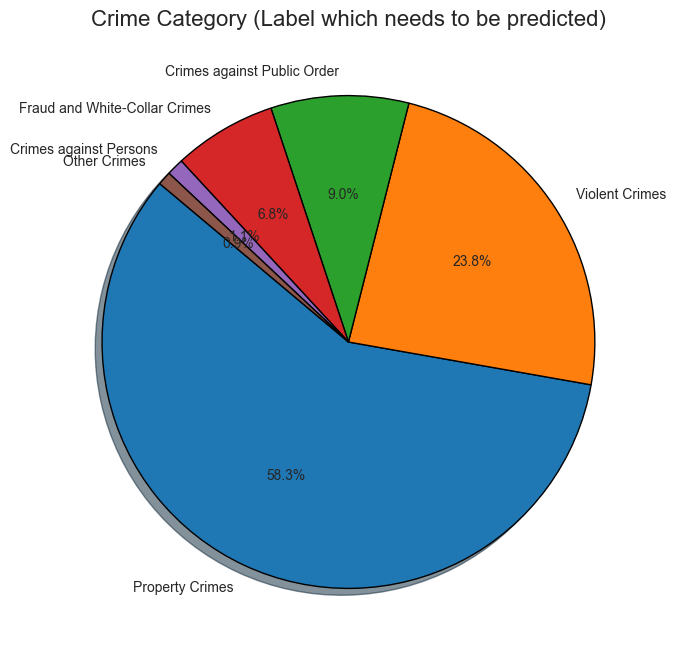

In [61]:
values = pd.Series(data_train['Crime_Category'])
v_counts = values.value_counts()

# Plotting the pie chart
fig = plt.figure(figsize=(8, 8))  
plt.title("Crime Category (Label which needs to be predicted)", fontsize=16)
plt.pie(v_counts, labels=v_counts.index, autopct='%1.1f%%', shadow=True, startangle=140, wedgeprops={'edgecolor': 'black', 'linewidth': 1})

# Display the plot
plt.show()

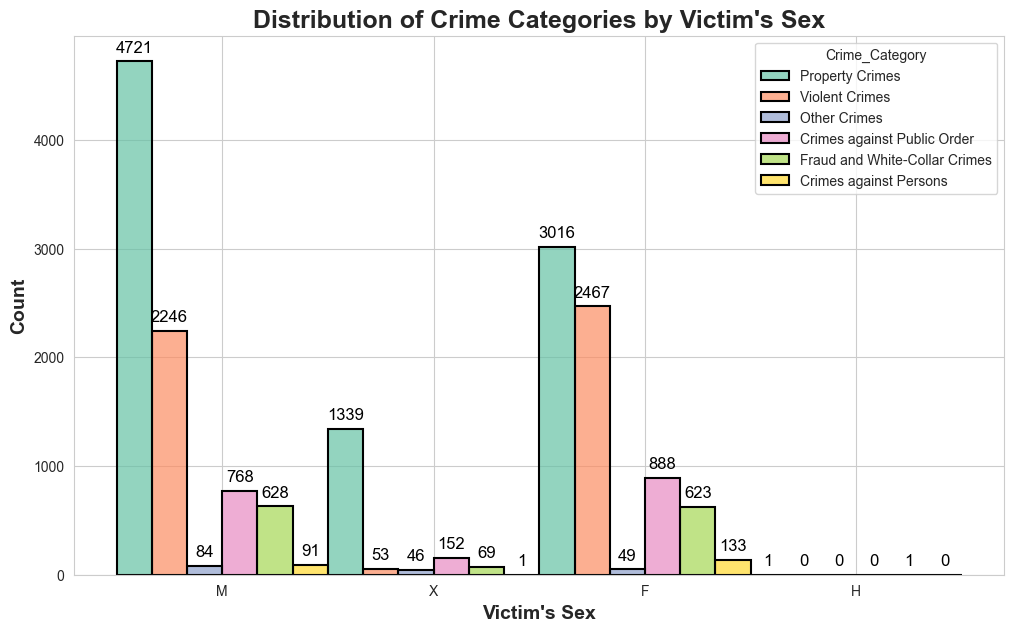

In [62]:
# Plotting Victim_Sex and crime category
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

sns.histplot(
    data=data_train,
    x='Victim_Sex',
    hue='Crime_Category',
    multiple='dodge',
    palette="Set2",  
    edgecolor="black", 
    linewidth=1.5, 
    alpha=0.7, 
    ax=ax
)

ax.set_title("Distribution of Crime Categories by Victim's Sex", fontsize=18, fontweight='bold')
ax.set_xlabel("Victim's Sex", fontsize=14, fontweight='bold')
ax.set_ylabel("Count", fontsize=14, fontweight='bold')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                fontsize=12, color='black')
plt.show()


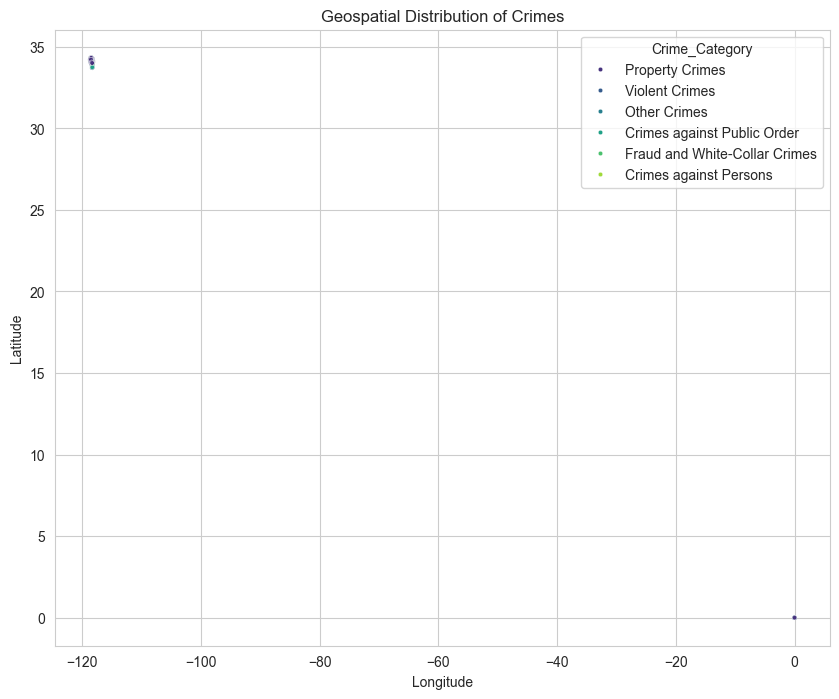

In [63]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Longitude', y='Latitude', hue='Crime_Category', data=data_train, palette='viridis', s=10)
plt.title('Geospatial Distribution of Crimes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [64]:
print(data_test[['Latitude', 'Longitude']].describe())

          Latitude    Longitude
count  5000.000000  5000.000000
mean     33.957169  -117.952663
std       1.986742     6.890957
min       0.000000  -118.650300
25%      34.010800  -118.431200
50%      34.058000  -118.323200
75%      34.162250  -118.274600
max      34.327500     0.000000


In [65]:
# Replace zero values with NaN
X['Latitude'].replace(0, np.nan, inplace=True)
X['Longitude'].replace(0, np.nan, inplace=True)
data_test['Latitude'].replace(0, np.nan, inplace=True)
data_test['Longitude'].replace(0, np.nan, inplace=True)

# Replace NaN values with the mean of the column
X['Latitude'].fillna(data_train['Latitude'].mean(), inplace=True)
X['Longitude'].fillna(data_train['Longitude'].mean(), inplace=True)
data_test['Latitude'].fillna(data_test['Latitude'].mean(), inplace=True)
data_test['Longitude'].fillna(data_test['Longitude'].mean(), inplace=True)


C:\Users\Aryan Raj\AppData\Local\Temp\ipykernel_16284\1910742703.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Latitude'].replace(0, np.nan, inplace=True)
C:\Users\Aryan Raj\AppData\Local\Temp\ipykernel_16284\1910742703.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

C:\Users\Aryan Raj\AppData\Local\Temp\ipykernel_16284\3109544696.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Crime_Category', y='Victim_Age', data=data_train, palette="coolwarm")


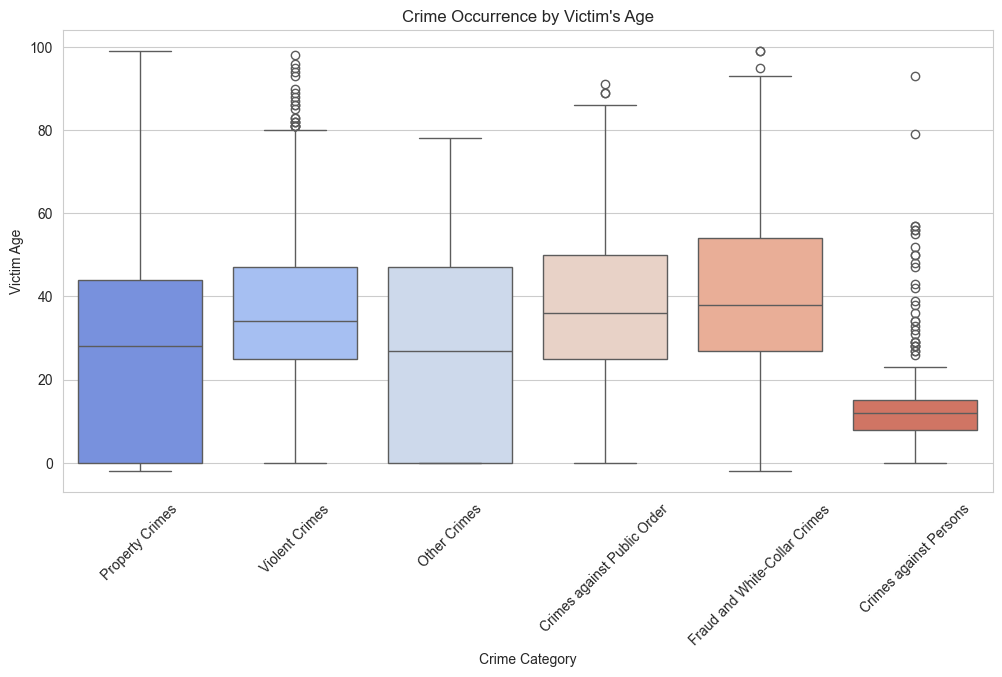

In [66]:
# Crime Occurrence by Age
plt.figure(figsize=(12, 6))
sns.boxplot(x='Crime_Category', y='Victim_Age', data=data_train, palette="coolwarm")
plt.title("Crime Occurrence by Victim's Age")
plt.xlabel("Crime Category")
plt.ylabel("Victim Age")
plt.xticks(rotation=45)
plt.show()

In [67]:
X['Victim_Age'].min()

np.float64(-2.0)

In [68]:
X['Victim_Age'] = X['Victim_Age'].where(X['Victim_Age'] > 0, np.nan)  # Replace with NaN where age <= 0
data_test['Victim_Age'] = data_test['Victim_Age'].where(data_test['Victim_Age'] > 0, np.nan)  

In [69]:
# Converting necessary columns to string
columns_to_convert = ['Area_ID', 'Reporting_District_no', 'Part 1-2', 'Premise_Code', 'Weapon_Used_Code']

for column in columns_to_convert:
    X[column] = X[column].astype(str)
    data_test[column] = data_test[column].astype(str)


In [70]:
#handling Null values in "Weapon_Used_Code" column

X['Weapon_Used_Code'] = X['Weapon_Used_Code'].fillna("No weapon")
data_test['Weapon_Used_Code'] = data_test['Weapon_Used_Code'].fillna("No weapon")

In [71]:
# Dropping unnecessary columns
X = X.drop(columns=['Location','Cross_Street','Area_Name', 'Weapon_Description', 'Premise_Description', 'Status_Description'])
data_test = data_test.drop(columns=['Location','Cross_Street','Area_Name', 'Weapon_Description', 'Premise_Description', 'Status_Description'])

In [72]:
X['Modus_Operandi'].value_counts()

Modus_Operandi
0344                             826
0329                             583
1501                             187
0329 1300                        135
0325                             127
                                ... 
2034                               1
2000 0419 0444 1814 0913           1
0913 1402 0421 0334 2000 1814      1
0344 0352 1601 1602 0397           1
1822 1609 0344 0358                1
Name: count, Length: 10489, dtype: int64

In [73]:
#handling Null values in "Modus_Operandi" column

X['Modus_Operandi'] = X['Modus_Operandi'].fillna("0000")
data_test['Modus_Operandi'] = data_test['Modus_Operandi'].fillna("0000")

In [74]:
# Using TF-IDF Vectorizer on "Modus_Operandi" column
tfidf = TfidfVectorizer()
modus_tfidf = tfidf.fit_transform(X['Modus_Operandi'])
modus_tfidf_df = pd.DataFrame(modus_tfidf.toarray(), columns=tfidf.get_feature_names_out())

X = pd.concat([X.reset_index(drop=True), modus_tfidf_df.reset_index(drop=True)], axis=1)
X.drop(columns=['Modus_Operandi'], inplace=True)

modus_tfidf_test = tfidf.transform(data_test['Modus_Operandi'])
modus_tfidf_test_df = pd.DataFrame(modus_tfidf_test.toarray(), columns=tfidf.get_feature_names_out())

data_test = pd.concat([data_test.reset_index(drop=True), modus_tfidf_test_df.reset_index(drop=True)], axis=1)
data_test.drop(columns=['Modus_Operandi'], inplace=True)


In [75]:
X

,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Reporting_District_no,Part 1-2,Victim_Age,Victim_Sex,...,2126,2157,2201,2204,2303,2304,3003,3004,4025,9999
0,34.1522,-118.3910,03/09/2020 12:00:00 AM,03/06/2020 12:00:00 AM,1800.0,15.0,1563.0,1.0,75.0,M,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,34.0028,-118.2391,02/27/2020 12:00:00 AM,02/27/2020 12:00:00 AM,1345.0,13.0,1367.0,1.0,41.0,M,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,34.0111,-118.2653,08/21/2020 12:00:00 AM,08/21/2020 12:00:00 AM,605.0,13.0,1343.0,2.0,67.0,M,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,34.2953,-118.4590,11/08/2020 12:00:00 AM,11/06/2020 12:00:00 AM,1800.0,19.0,1924.0,1.0,61.0,M,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,33.9787,-118.2918,02/25/2020 12:00:00 AM,02/25/2020 12:00:00 AM,1130.0,12.0,1245.0,1.0,NaN,X,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,34.0334,-118.3523,05/24/2020 12:00:00 AM,05/24/2020 12:00:00 AM,700.0,3.0,303.0,2.0,51.0,M,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19996,34.2212,-118.5011,12/25/2020 12:00:00 AM,12/25/2020 12:00:00 AM,259.0,10.0,1008.0,1.0,NaN,M,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19997,34.0571,-118.3815,09/25/2020 12:00:00 AM,09/25/2020 12:00:00 AM,1400.0,8.0,849.0,1.0,42.0,M,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19998,33.7451,-118.2835,06/10/2020 12:00:00 AM,06/10/2020 12:00:00 AM,600.0,5.0,558.0,2.0,76.0,F,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [76]:
# For training data
X['Date_Occurred'] = pd.to_datetime(X['Date_Occurred'], errors='coerce')
X['Date_Reported'] = pd.to_datetime(X['Date_Reported'], errors='coerce')
X['Days_To_Report_Crime'] = (X['Date_Reported'] - X['Date_Occurred']).dt.days
X = X.drop(columns=['Date_Occurred', 'Date_Reported'])

# For test data
data_test['Date_Occurred'] = pd.to_datetime(data_test['Date_Occurred'], errors='coerce')
data_test['Date_Reported'] = pd.to_datetime(data_test['Date_Reported'], errors='coerce')
data_test['Days_To_Report_Crime'] = (data_test['Date_Reported'] - data_test['Date_Occurred']).dt.days
data_test = data_test.drop(columns=['Date_Occurred', 'Date_Reported'])

C:\Users\Aryan Raj\AppData\Local\Temp\ipykernel_16284\502639133.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['Date_Occurred'] = pd.to_datetime(X['Date_Occurred'], errors='coerce')
C:\Users\Aryan Raj\AppData\Local\Temp\ipykernel_16284\502639133.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['Date_Reported'] = pd.to_datetime(X['Date_Reported'], errors='coerce')
C:\Users\Aryan Raj\AppData\Local\Temp\ipykernel_16284\502639133.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_test['Date_Occurred'] = pd.to_datetime(data_test['Date_Occurred'], errors='coerce

In [77]:
X

,Latitude,Longitude,Time_Occurred,Area_ID,Reporting_District_no,Part 1-2,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,...,2157,2201,2204,2303,2304,3003,3004,4025,9999,Days_To_Report_Crime
0,34.1522,-118.3910,1800.0,15.0,1563.0,1.0,75.0,M,W,101.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1,34.0028,-118.2391,1345.0,13.0,1367.0,1.0,41.0,M,H,216.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,34.0111,-118.2653,605.0,13.0,1343.0,2.0,67.0,M,B,501.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,34.2953,-118.4590,1800.0,19.0,1924.0,1.0,61.0,M,H,101.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,33.9787,-118.2918,1130.0,12.0,1245.0,1.0,NaN,X,X,401.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,34.0334,-118.3523,700.0,3.0,303.0,2.0,51.0,M,H,501.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
19996,34.2212,-118.5011,259.0,10.0,1008.0,1.0,NaN,M,W,301.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
19997,34.0571,-118.3815,1400.0,8.0,849.0,1.0,42.0,M,H,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
19998,33.7451,-118.2835,600.0,5.0,558.0,2.0,76.0,F,H,501.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [78]:
# Imputing missing values for numerical columns
mean_imputer = SimpleImputer(strategy="mean")
X['Victim_Age'] = mean_imputer.fit_transform(X[['Victim_Age']]).ravel()
data_test['Victim_Age'] = mean_imputer.transform(data_test[['Victim_Age']]).ravel()

# Filling most frequent values for categorical features
categorical_cols_with_nan = ['Victim_Sex', 'Victim_Descent']
for col in categorical_cols_with_nan:
    most_frequent = X[col].mode()[0]
    X[col].fillna(most_frequent, inplace=True)
    data_test[col].fillna(most_frequent, inplace=True)

# One-Hot Encoding for categorical features
categorical_cols = [
    'Area_ID',
    'Reporting_District_no',
    'Part 1-2',
    'Premise_Code',
    'Weapon_Used_Code',
    'Status',
    'Victim_Sex',
    'Victim_Descent'
]

# Updated for newer sklearn versions
one_hot_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

# Fitting on the training data
X_encoded = one_hot_encoder.fit_transform(X[categorical_cols])

X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=one_hot_encoder.get_feature_names_out(categorical_cols)
)

# Transforming the test data
data_test_encoded = one_hot_encoder.transform(
    data_test[categorical_cols]
)

data_test_encoded_df = pd.DataFrame(
    data_test_encoded,
    columns=one_hot_encoder.get_feature_names_out(categorical_cols)
)

# Dropping original categorical columns and concatenate the new encoded columns
X = X.drop(columns=categorical_cols)

X = pd.concat(
    [X.reset_index(drop=True),
     X_encoded_df.reset_index(drop=True)],
    axis=1
)

data_test = data_test.drop(columns=categorical_cols)

data_test = pd.concat(
    [data_test.reset_index(drop=True),
     data_test_encoded_df.reset_index(drop=True)],
    axis=1
)

C:\Users\Aryan Raj\AppData\Local\Temp\ipykernel_16284\2944244606.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(most_frequent, inplace=True)
C:\Users\Aryan Raj\AppData\Local\Temp\ipykernel_16284\2944244606.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [79]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
X_train

,Latitude,Longitude,Time_Occurred,Victim_Age,0000,0100,0104,0105,0110,0112,...,Victim_Descent_I,Victim_Descent_J,Victim_Descent_K,Victim_Descent_O,Victim_Descent_P,Victim_Descent_U,Victim_Descent_V,Victim_Descent_W,Victim_Descent_X,Victim_Descent_Z
5894,34.0257,-118.2139,2355.0,25.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3728,34.0588,-118.2221,1230.0,29.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8958,33.9850,-118.4714,1425.0,24.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7671,34.0835,-118.3245,1300.0,50.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5999,34.2157,-118.3703,1725.0,31.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,34.0478,-118.2484,330.0,36.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11964,34.1225,-118.1818,1500.0,39.740736,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5390,34.0790,-118.3236,1100.0,39.740736,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,33.9627,-118.3178,1230.0,34.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [81]:
y_train

5894     Property Crimes
3728      Violent Crimes
8958     Property Crimes
7671     Property Crimes
5999     Property Crimes
              ...       
11284     Violent Crimes
11964    Property Crimes
5390     Property Crimes
860       Violent Crimes
15795    Property Crimes
Name: Crime_Category, Length: 16000, dtype: object

In [85]:
# Logistic Regression
log_model = LogisticRegression(
    max_iter=100,
    n_jobs=-1
)

print("\nTraining Logistic Regression...")

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print(classification_report(y_val, y_pred))

print(confusion_matrix(y_val, y_pred))


Training Logistic Regression...
Accuracy: 0.5820
                               precision    recall  f1-score   support

       Crimes against Persons       0.00      0.00      0.00        32
  Crimes against Public Order       0.00      0.00      0.00       374
Fraud and White-Collar Crimes       0.67      0.12      0.20       267
                 Other Crimes       0.00      0.00      0.00        35
              Property Crimes       0.58      1.00      0.73      2303
               Violent Crimes       0.00      0.00      0.00       989

                     accuracy                           0.58      4000
                    macro avg       0.21      0.19      0.16      4000
                 weighted avg       0.38      0.58      0.44      4000

[[   0    0    1    0   31    0]
 [   0    0    1    0  373    0]
 [   0    0   31    0  236    0]
 [   0    0    0    0   35    0]
 [   0    0    6    0 2297    0]
 [   0    0    7    0  982    0]]


c:\Users\Aryan Raj\Desktop\Projectsss\venvvv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Aryan Raj\Desktop\Projectsss\venvvv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Aryan Raj\Desktop\Projectsss\venvvv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [86]:
# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=10
)

print("\nTraining Decision Tree...")

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print(classification_report(y_val, y_pred))

print(confusion_matrix(y_val, y_pred))


Training Decision Tree...
Accuracy: 0.9397
                               precision    recall  f1-score   support

       Crimes against Persons       0.70      0.44      0.54        32
  Crimes against Public Order       0.78      0.79      0.79       374
Fraud and White-Collar Crimes       0.96      0.87      0.91       267
                 Other Crimes       0.00      0.00      0.00        35
              Property Crimes       0.99      0.98      0.99      2303
               Violent Crimes       0.89      0.97      0.93       989

                     accuracy                           0.94      4000
                    macro avg       0.72      0.68      0.69      4000
                 weighted avg       0.93      0.94      0.94      4000

[[  14    2    0    0    0   16]
 [   1  295    4    2    9   63]
 [   0   32  233    0    1    1]
 [   0   27    5    0    2    1]
 [   0    5    1    0 2254   43]
 [   5   15    0    0    6  963]]


In [87]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest...")

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print(classification_report(y_val, y_pred))

print(confusion_matrix(y_val, y_pred))


Training Random Forest...
Accuracy: 0.9480
                               precision    recall  f1-score   support

       Crimes against Persons       0.50      0.12      0.20        32
  Crimes against Public Order       0.87      0.81      0.84       374
Fraud and White-Collar Crimes       0.94      0.94      0.94       267
                 Other Crimes       1.00      0.06      0.11        35
              Property Crimes       0.98      0.98      0.98      2303
               Violent Crimes       0.90      0.98      0.94       989

                     accuracy                           0.95      4000
                    macro avg       0.87      0.65      0.67      4000
                 weighted avg       0.95      0.95      0.94      4000

[[   4    5    1    0    1   21]
 [   2  303    6    0   17   46]
 [   0   14  250    0    3    0]
 [   0   17    7    2    9    0]
 [   0    1    2    0 2263   37]
 [   2    8    0    0    9  970]]


In [89]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Perform cross-validation
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5)
print(f"Random Forest Cross-Validation Accuracy: {rf_cv_scores.mean()}")

Random Forest Cross-Validation Accuracy: 0.9500499999999998


In [91]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Reduced parameter grid (faster and memory efficient)
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}

# Random Forest Model
rf = RandomForestClassifier(
    random_state=42
)

# Grid Search
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=3,
    verbose=3
)

# Fit model
grid_search_rf.fit(X_train, y_train)

# Best model
best_rf_model = grid_search_rf.best_estimator_

# Prediction
rf_pred = best_rf_model.predict(X_val)

# Results
print("Best Parameters:")
print(grid_search_rf.best_params_)

print("\nRandom Forest Classifier Report:")

print(classification_report(y_val, rf_pred))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV 1/3] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.795 total time=   2.7s
[CV 2/3] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.812 total time=   2.2s
[CV 3/3] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.817 total time=   1.9s
[CV 1/3] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.800 total time=   3.5s
[CV 2/3] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.816 total time=   4.0s
[CV 3/3] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.817 total time=   3.8s
[CV 1/3] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=50;, score=0.795 total time=   2.0s
[CV 2

c:\Users\Aryan Raj\Desktop\Projectsss\venvvv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Aryan Raj\Desktop\Projectsss\venvvv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Aryan Raj\Desktop\Projectsss\venvvv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [92]:
print(best_rf_model.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [93]:
# Predict on the test set with the best model
test_pred = best_rf_model.predict(data_test)  # Assuming test_df is your test DataFrame
print(test_pred)

['Violent Crimes' 'Property Crimes' 'Fraud and White-Collar Crimes' ...
 'Violent Crimes' 'Violent Crimes' 'Property Crimes']


In [94]:
submission = pd.DataFrame({"ID": np.arange(1,5001), 
                           "Crime_Category": test_pred,
                          }
                         ) 

submission.to_csv('submission.csv',index=False)